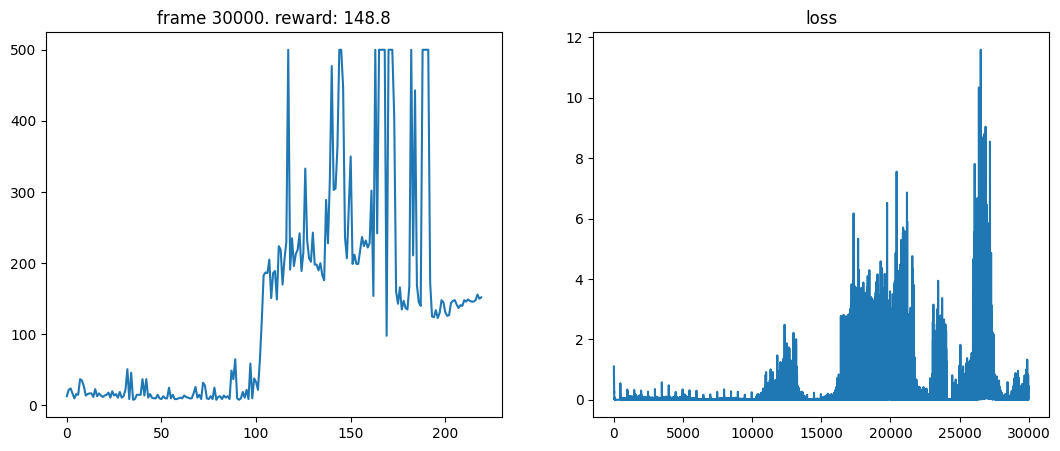

Обучение завершено!
Средняя награда за последние 10 эпизодов: 148.80


In [ ]:
import math, random
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import clear_output

print(f"Gymnasium: {gym.__version__}")
print(f"NumPy: {np.__version__}")

class ReplayBuffer(object):
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        state = np.expand_dims(state, 0)
        next_state = np.expand_dims(next_state, 0)
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        return np.concatenate(state), action, reward, np.concatenate(next_state), done
    
    def __len__(self):
        return len(self.buffer)

env = gym.make("CartPole-v1")

epsilon_start = 1.0
epsilon_final = 0.01
epsilon_decay = 500
epsilon_by_frame = lambda frame_idx: epsilon_final + (epsilon_start - epsilon_final) * math.exp(-1. * frame_idx / epsilon_decay)

class DQN(nn.Module):
    def __init__(self, num_inputs, num_actions):
        super(DQN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(num_inputs, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_actions)
        )
        
    def forward(self, x):
        return self.layers(x)
    
    def act(self, state, epsilon):
        if random.random() > epsilon:
            with torch.no_grad():
                state = torch.FloatTensor(state).unsqueeze(0)
                q_value = self.forward(state)
                action = q_value.max(1)[1].item()
        else:
            action = random.randrange(env.action_space.n)
        return action

def plot(frame_idx, rewards, losses):
    clear_output(True)
    plt.figure(figsize=(20,5))
    plt.subplot(131)
    plt.title('frame %s. reward: %s' % (frame_idx, np.mean(rewards[-10:])))
    plt.plot(rewards)
    plt.subplot(132)
    plt.title('loss')
    plt.plot(losses)
    plt.show()

class NaivePrioritizedBuffer(object):
    def __init__(self, capacity, prob_alpha=0.4):
        self.prob_alpha = prob_alpha
        self.capacity = capacity
        self.buffer = []
        self.pos = 0
        self.priorities = np.zeros((capacity,), dtype=np.float32)
    
    def push(self, state, action, reward, next_state, done):
        state = np.expand_dims(state, 0)
        next_state = np.expand_dims(next_state, 0)
        max_prio = self.priorities.max() if self.buffer else 1.0
        
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
        else:
            self.buffer[self.pos] = (state, action, reward, next_state, done)
        
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.capacity
    
    def sample(self, batch_size, beta=0.4):
        if len(self.buffer) == self.capacity:
            prios = self.priorities
        else:
            prios = self.priorities[:self.pos]
        
        probs = prios ** self.prob_alpha
        probs /= probs.sum()
        
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]
        
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()
        weights = np.array(weights, dtype=np.float32)
        
        batch = list(zip(*samples))
        states = np.concatenate(batch[0])
        actions = batch[1]
        rewards = batch[2]
        next_states = np.concatenate(batch[3])
        dones = batch[4]
        
        return states, actions, rewards, next_states, dones, indices, weights
    
    def update_priorities(self, batch_indices, batch_priorities):
        for idx, prio in zip(batch_indices, batch_priorities):
            self.priorities[idx] = prio

    def __len__(self):
        return len(self.buffer)

def update_target(current_model, target_model):
    target_model.load_state_dict(current_model.state_dict())

beta_start = 0.4
beta_frames = 2000
beta_by_frame = lambda frame_idx: min(1.0, beta_start + frame_idx * (1.0 - beta_start) / beta_frames)

def compute_td_loss(batch_size, beta, gamma, current_model, target_model, optimizer, replay_buffer):
    state, action, reward, next_state, done, indices, weights = replay_buffer.sample(batch_size, beta)

    state = torch.FloatTensor(np.float32(state))
    next_state = torch.FloatTensor(np.float32(next_state))
    action = torch.LongTensor(action)
    reward = torch.FloatTensor(reward)
    done = torch.FloatTensor(done)
    weights = torch.FloatTensor(weights)

    q_values = current_model(state)
    next_q_values = target_model(next_state)

    q_value = q_values.gather(1, action.unsqueeze(1)).squeeze(1)
    next_q_value = next_q_values.max(1)[0]
    expected_q_value = reward + gamma * next_q_value * (1 - done)
    
    td_error = q_value - expected_q_value
    prios = torch.abs(td_error).detach().numpy() + 1e-6
    loss = (weights * td_error.pow(2)).mean()
        
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(current_model.parameters(), 1.0)
    replay_buffer.update_priorities(indices, prios)
    optimizer.step()
    
    return loss.item()

current_model = DQN(env.observation_space.shape[0], env.action_space.n)
target_model = DQN(env.observation_space.shape[0], env.action_space.n)

optimizer = optim.Adam(current_model.parameters(), lr=0.0005)
replay_buffer = NaivePrioritizedBuffer(1000, prob_alpha=0.4)
update_target(current_model, target_model)

num_frames = 30000
batch_size = 32
gamma = 0.99

losses = []
all_rewards = []
episode_reward = 0

state, _ = env.reset()

for frame_idx in range(1, num_frames + 1):
    epsilon = epsilon_by_frame(frame_idx)
    action = current_model.act(state, epsilon)
    
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    
    replay_buffer.push(state, action, reward, next_state, done)
    
    state = next_state
    episode_reward += reward
    
    if done:
        state, _ = env.reset()
        all_rewards.append(episode_reward)
        episode_reward = 0
        
    if len(replay_buffer) > batch_size:
        beta = beta_by_frame(frame_idx)
        loss = compute_td_loss(batch_size, beta, gamma, current_model, target_model, optimizer, replay_buffer)
        losses.append(loss)
        
    if frame_idx % 200 == 0:
        plot(frame_idx, all_rewards, losses)
        
    if frame_idx % 500 == 0:
        update_target(current_model, target_model)

print(f"Средняя награда за последние 10 эпизодов: {np.mean(all_rewards[-10:]):.2f}")

<h2>Replay Buffer</h2>

<h2>Cart Pole Environment</h2>

<h2>Epsilon greedy exploration</h2>

<h2>Deep Q Network</h2>

<h2>Computing Temporal Difference Loss</h2>

<h2>Training</h2>

<h2>Prioritized Replay Buffer (5 pts)</h2>

Не забудте про importance sampling

<p><hr></p>